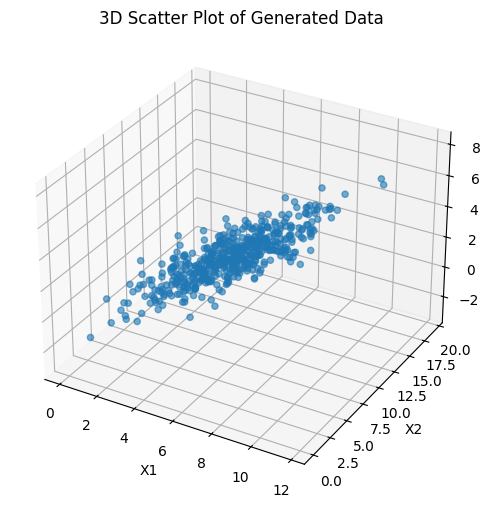

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# For inline plotting in Jupyter
%matplotlib inline

np.random.seed(1)

mean = [5, 10, 2]
cov = [[3, 2, 2], [2, 10, 1], [2, 1, 2]]

X = np.random.multivariate_normal(mean, cov, 500)

# 3D scatter plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], alpha=0.6)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('X3')
ax.set_title('3D Scatter Plot of Generated Data')
plt.show()

In [ ]:
X_centered = X - np.mean(X, axis=0)

cov_matrix = np.cov(X_centered, rowvar=False)

eigvals, eigvecs = np.linalg.eigh(cov_matrix)

# eigenvalues and eigenvectors in descending order
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

print('Eigenvalues:', eigvals)
print('Eigenvectors (columns):\n', eigvecs)

Eigenvalues: [10.17236182  3.96251129  0.40781907]
Eigenvectors (columns):
 [[-0.33467265  0.70371891  0.62671677]
 [-0.92026157 -0.38717689 -0.0566806 ]
 [-0.20276304  0.59571281 -0.77718299]]


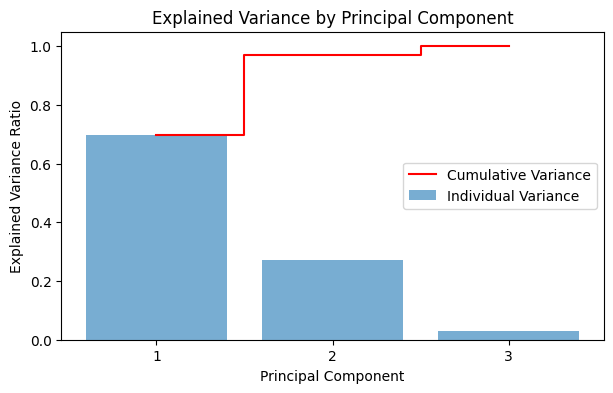

In [ ]:
import matplotlib.pyplot as plt

explained_var = eigvals / np.sum(eigvals)
cum_explained_var = np.cumsum(explained_var)

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.bar(range(1, 4), explained_var, alpha=0.6, label='Individual Variance')
ax1.step(range(1, 4), cum_explained_var, where='mid', color='red', label='Cumulative Variance')
ax1.set_xticks([1, 2, 3])
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_title('Explained Variance by Principal Component')
ax1.legend()
plt.show()

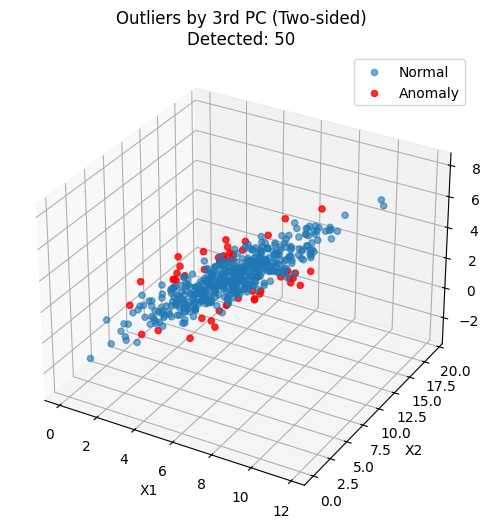

In [ ]:
X_pca = X_centered @ eigvecs

# 3rd principal component (index 2)
pc3 = X_pca[:, 2]
pc3_mean = np.mean(pc3)

# two-sided thresholding using quantiles
contamination = 0.1
lower_th = np.quantile(pc3, contamination / 2)
upper_th = np.quantile(pc3, 1 - contamination / 2)

outliers_pc3 = (pc3 < lower_th) | (pc3 > upper_th)
num_outliers_pc3 = np.sum(outliers_pc3)

# plot with anomalies highlighted
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[~outliers_pc3, 0], X[~outliers_pc3, 1], X[~outliers_pc3, 2], alpha=0.6, label='Normal')
ax.scatter(X[outliers_pc3, 0], X[outliers_pc3, 1], X[outliers_pc3, 2], color='red', alpha=0.8, label='Anomaly')
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('X3')
ax.set_title(f'Outliers by 3rd PC (Two-sided)\nDetected: {num_outliers_pc3}')
ax.legend()
plt.show()

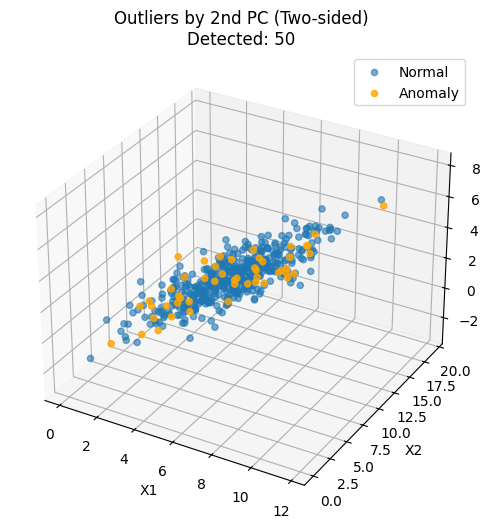

In [ ]:
pc2 = X_pca[:, 1]
pc2_mean = np.mean(pc2)

lower_th2 = np.quantile(pc2, contamination / 2)
upper_th2 = np.quantile(pc2, 1 - contamination / 2)

outliers_pc2 = (pc2 < lower_th2) | (pc2 > upper_th2)
num_outliers_pc2 = np.sum(outliers_pc2)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[~outliers_pc2, 0], X[~outliers_pc2, 1], X[~outliers_pc2, 2], alpha=0.6, label='Normal')
ax.scatter(X[outliers_pc2, 0], X[outliers_pc2, 1], X[outliers_pc2, 2], color='orange', alpha=0.8, label='Anomaly')
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('X3')
ax.set_title(f'Outliers by 2nd PC (Two-sided)\nDetected: {num_outliers_pc2}')
ax.legend()
plt.show()

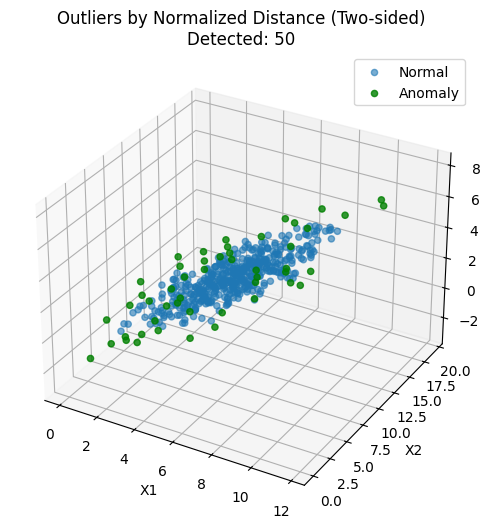

In [ ]:
centroid = np.mean(X_pca, axis=0)
stds = np.std(X_pca, axis=0)

# avoid division by zero
stds[stds == 0] = 1

# normalized distances
normed = (X_pca - centroid) / stds
norm_dist = np.linalg.norm(normed, axis=1)

# two-sided thresholding (upper only, since distances are >=0)
upper_th_dist = np.quantile(norm_dist, 1 - contamination)
outliers_dist = norm_dist > upper_th_dist
num_outliers_dist = np.sum(outliers_dist)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[~outliers_dist, 0], X[~outliers_dist, 1], X[~outliers_dist, 2], alpha=0.6, label='Normal')
ax.scatter(X[outliers_dist, 0], X[outliers_dist, 1], X[outliers_dist, 2], color='green', alpha=0.8, label='Anomaly')
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('X3')
ax.set_title(f'Outliers by Normalized Distance (Two-sided)\nDetected: {num_outliers_dist}')
ax.legend()
plt.show()